In [1]:
import sys
sys.path.insert(0, '../lib')

In [2]:
import os
import copy
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import sc_utils

import common_data
import common_plots

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%config InlineBackend.figure_format = "retina"

In [4]:
pd.options.display.max_columns = 200

In [5]:
common_plots.setup_plotting()

In [6]:
ds = sc.read_h5ad(common_data.SC_NORM)

In [7]:
ds.shape

(2438672, 1000)

In [8]:
ds.raw.shape

(2438672, 19488)

In [9]:
ds.obs.Level_6.value_counts()

NUPR1+ Macs                   642717
MRC1+C1QA-                    431279
CD8 T cells                   313724
MRC1+C1QA+                    267143
CD4 T cells                   237440
Classical monocytes-2 IL1B    170317
gdT cells                      49335
Proliferating plasma cells     33766
Plasma cells                   29780
Proliferating NUPR1+ Macs      29515
DC2                            28659
Classical monocytes-1 CCR2     28480
Proliferating CD4 T cells      26565
Interstitial macrophages       21352
Ciliated cells                 21271
Proliferating CD8 T cells      21033
Tregs                          20376
Non-classical monocytes        12498
Secretory cells                12253
B cells                         9704
pDC                             7362
Mast cells                      5346
Hematopoietic stem cells        5147
DC1                             4287
AT1 and AT2                     3405
Migratory DC                    2943
Proliferating gdT cells         2460
I

In [10]:
T_CELLS = [
    'CD8 T cells',
    'CD4 T cells',
    'Tregs',
    'gdT cells',
    'Proliferating CD8 T cells',
    'Proliferating CD4 T cells',
    'Proliferating gdT cells'
]
MACS = [
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'Classical monocytes-2 IL1B',
    'Classical monocytes-1 CCR2',
    'Non-classical monocytes',
    'Proliferating NUPR1+ Macs',
    'Perivascular macrophages',
]

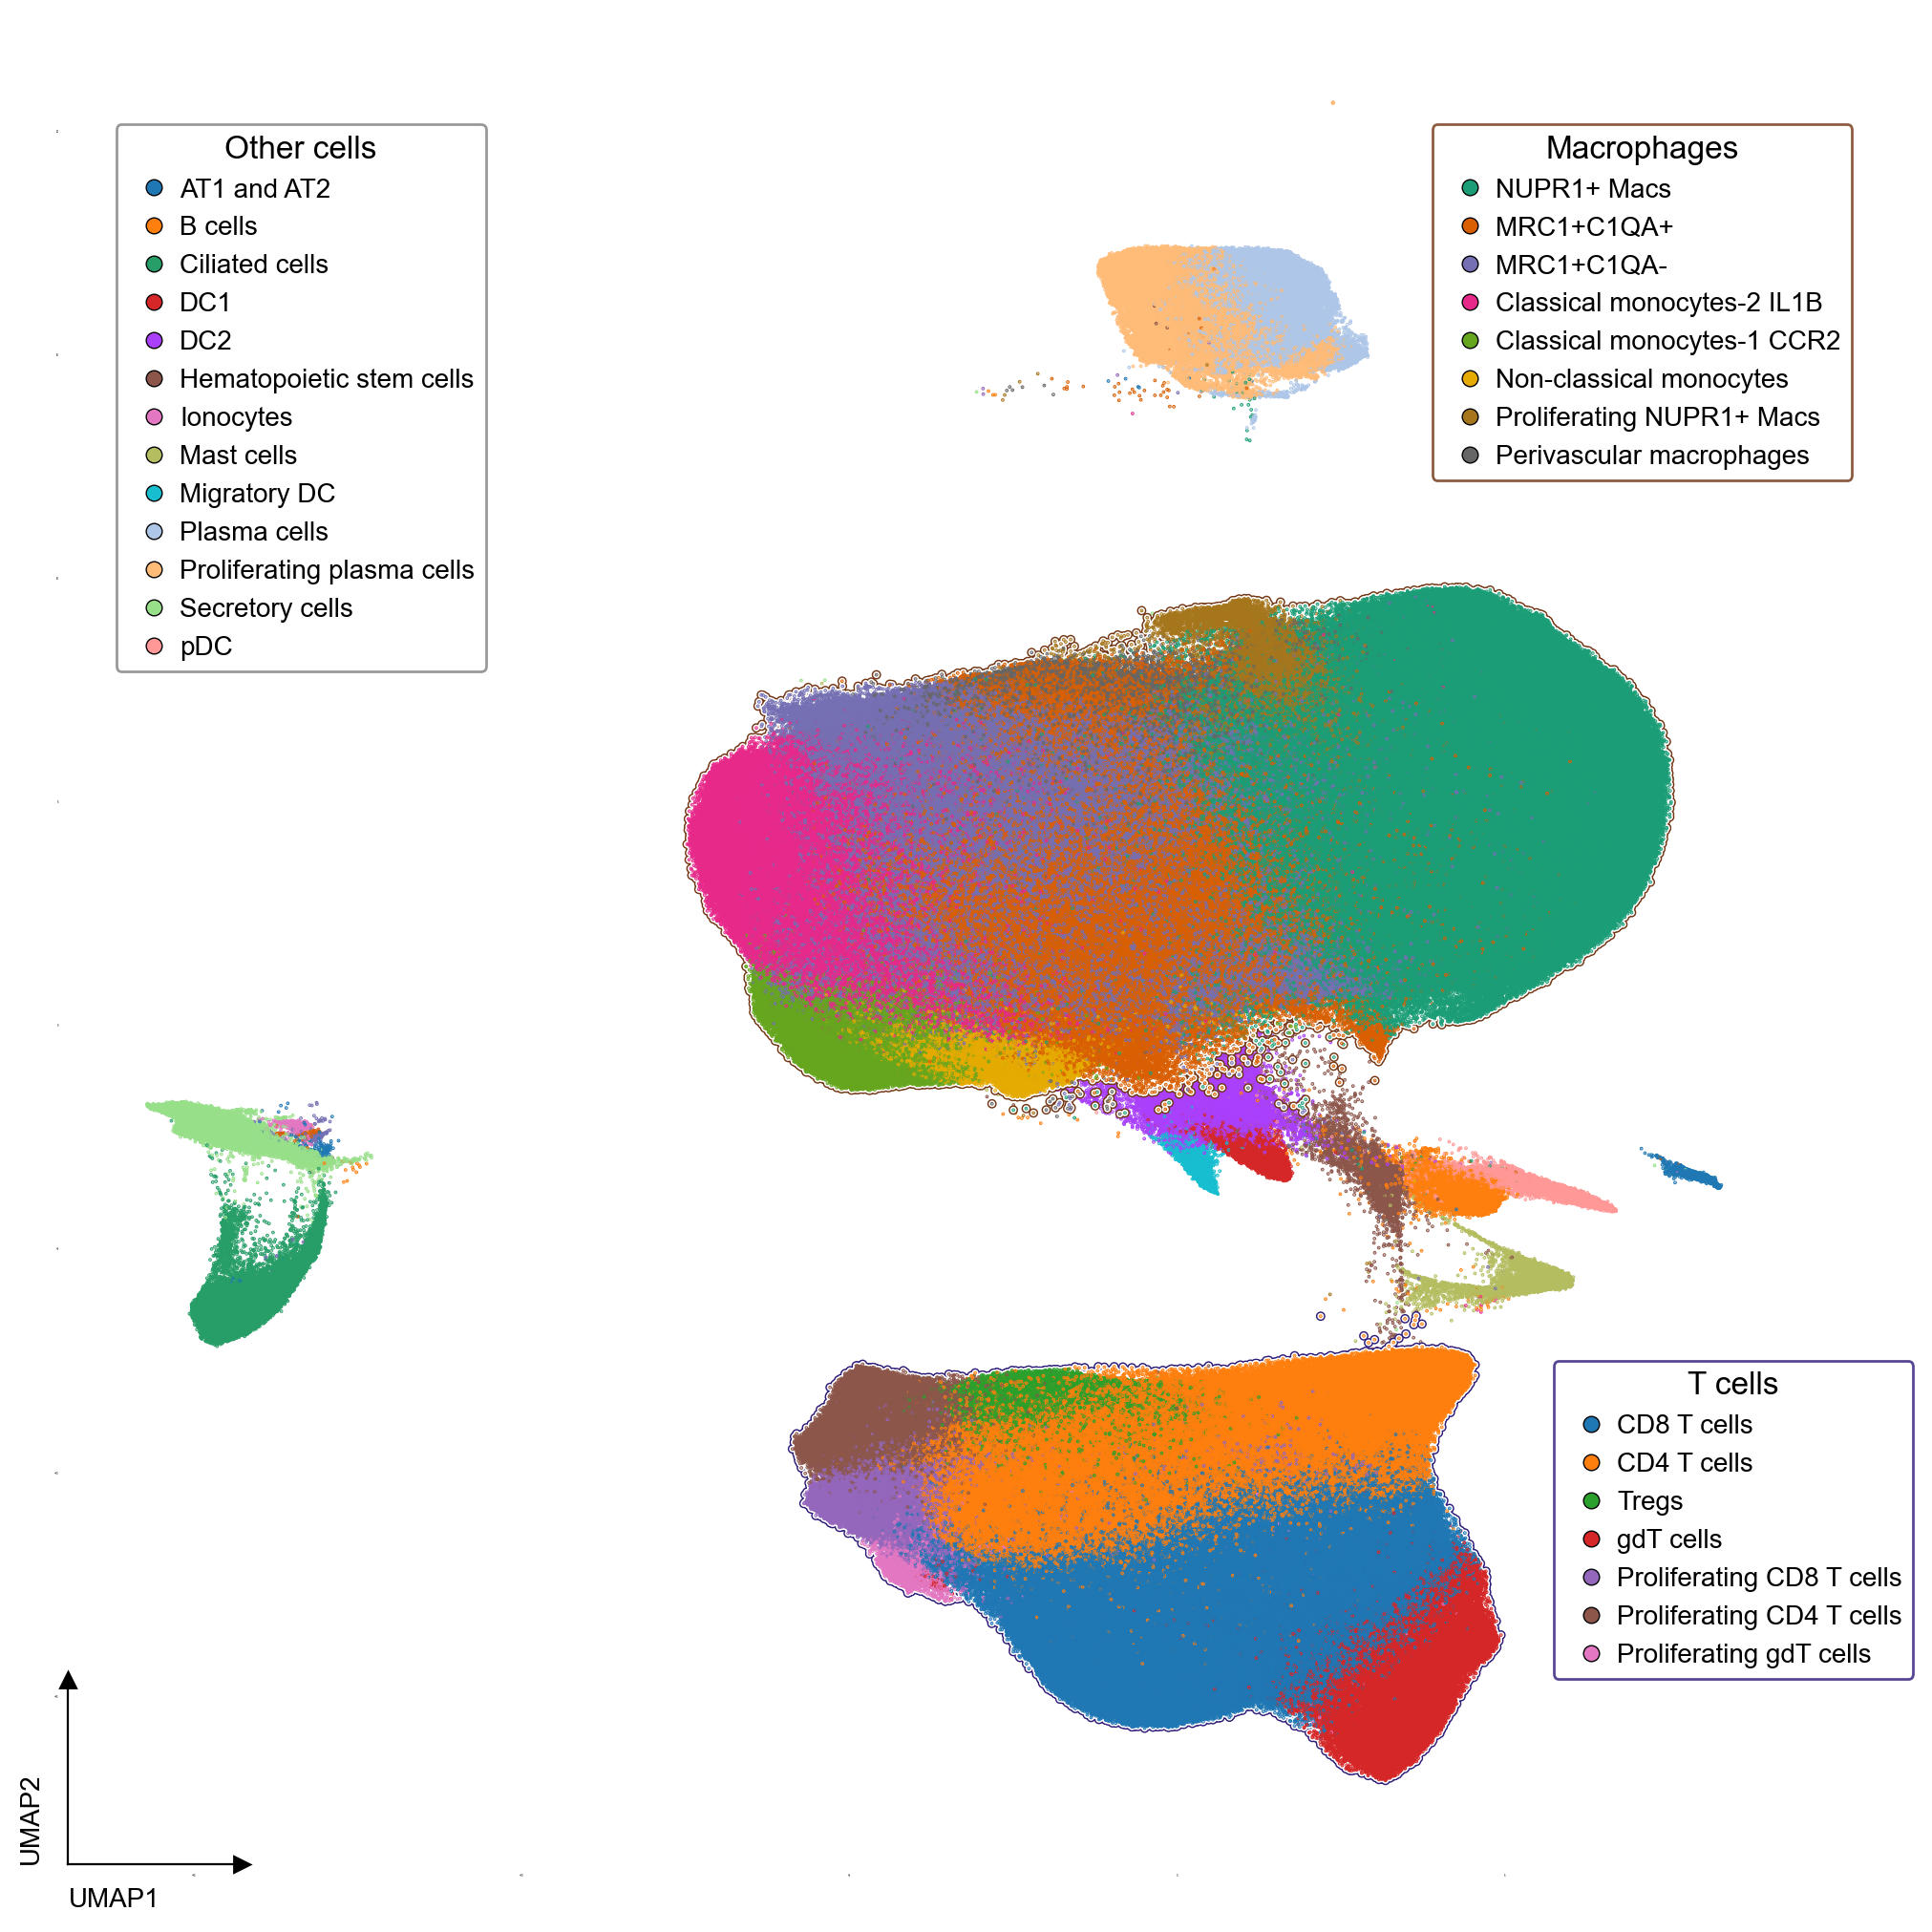

In [75]:
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)

cmap = {}
for i, cl in enumerate(MACS):
    cmap[cl] = mpl.colors.rgb2hex(mpl.cm.Dark2(i))
for i, cl in enumerate(T_CELLS):
    cmap[cl] = mpl.colors.rgb2hex(mpl.cm.tab10(i))
for cl in ds.obs.Level_6.cat.categories:
    if cl not in cmap:
        cmap[cl] = mpl.colors.rgb2hex(sc.pl.palettes.default_20[len(cmap) - len(T_CELLS) - len(MACS)])

colors = ds.obs.Level_6.map(cmap)

ax.scatter(ds.obsm['X_umap'][:, 0], ds.obsm['X_umap'][:, 1], c=colors, s=0.5, zorder=1, marker='.')

idx = (
    ds.obs.Level_6.isin(MACS)
    & (ds.obsm['X_umap'][:, 1] > -2)
    & (ds.obsm['X_umap'][:, 1] < 10)
    & (ds.obsm['X_umap'][:, 0] > -8)
)
ax.scatter(ds.obsm['X_umap'][idx, 0], ds.obsm['X_umap'][idx, 1], c=colors[idx], s=0.5, zorder=10, marker='.')
ax.scatter(ds.obsm['X_umap'][idx, 0], ds.obsm['X_umap'][idx, 1], facecolor='w', marker='.', s=25, zorder=6, edgecolor='none')
ax.scatter(ds.obsm['X_umap'][idx, 0], ds.obsm['X_umap'][idx, 1], facecolor='#723412', marker='.', s=50, zorder=5, edgecolor='none')

idx = (
    ds.obs.Level_6.isin(T_CELLS)
    & (ds.obsm['X_umap'][:, 1] < -6.5)
    & (ds.obsm['X_umap'][:, 0] > -10)
    & (ds.obsm['X_umap'][:, 0] < 5)
)
ax.scatter(ds.obsm['X_umap'][idx, 0], ds.obsm['X_umap'][idx, 1], c=colors[idx], s=0.5, zorder=10, marker='.')
ax.scatter(ds.obsm['X_umap'][idx, 0], ds.obsm['X_umap'][idx, 1], facecolor='w', marker='.', s=25, zorder=6, edgecolor='none')
ax.scatter(ds.obsm['X_umap'][idx, 0], ds.obsm['X_umap'][idx, 1], facecolor='#2d1977', marker='.', s=50, zorder=5, edgecolor='none')

shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel("UMAP1", x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel("UMAP2", y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for c in ax.collections:
    c.set_rasterized(True)

legend1 = ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            color=cmap[c],
            label=c,
            marker='o',
            linestyle='',
            markeredgecolor='k',
            markeredgewidth=0.5
        ) for c in MACS
    ],
    loc="upper left",
    bbox_to_anchor=(0.78, 0.95),
    fontsize=10,
    title="Macrophages",
    title_fontsize=12,
    edgecolor='#723412',
    handletextpad=0
)

legend2 =ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            color=cmap[c],
            label=c,
            marker='o',
            linestyle='',
            markeredgecolor='k',
            markeredgewidth=0.5
        ) for c in ds.obs.Level_6.cat.categories
        if c not in T_CELLS and c not in MACS
    ],
    loc="upper left",
    bbox_to_anchor=(0.02, 0.95),
    fontsize=10,
    title="Other cells",
    title_fontsize=12,
    edgecolor='gray',
    handletextpad=0
)

ax.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            color=cmap[c],
            label=c,
            marker='o',
            linestyle='',
            markeredgecolor='k',
            markeredgewidth=0.5
        ) for c in T_CELLS
    ],
    loc="upper left",
    bbox_to_anchor=(0.85, 0.28),
    fontsize=10,
    title="T cells",
    title_fontsize=12,
    edgecolor='#2d1977',
    handletextpad=0
)

ax.add_artist(legend1)
ax.add_artist(legend2)
ax.tick_params(size=0, labelsize=0)
fig.savefig('00_figures/Figure_2D_umap.pdf', dpi=300)

In [9]:
ds.uns

{'Level_1_colors': array(['#1f77b4', '#ff7f0e'], dtype=object),
 'Level_2_colors': array(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b',
        '#e377c2'], dtype=object),
 'Level_3_colors': array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
        '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
        '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2', '#dbdb8d', '#9edae5',
        '#ad494a', '#8c6d31'], dtype=object),
 'Level_4_colors': array(['#023fa5', '#7d87b9', '#bec1d4', '#d6bcc0', '#bb7784', '#8e063b',
        '#4a6fe3', '#8595e1', '#b5bbe3', '#e6afb9', '#e07b91', '#d33f6a',
        '#11c638', '#8dd593', '#c6dec7', '#ead3c6', '#f0b98d', '#ef9708',
        '#0fcfc0', '#9cded6', '#d5eae7', '#f3e1eb', '#f6c4e1', '#f79cd4',
        '#7f7f7f', '#c7c7c7', '#1ce6ff', '#336600'], dtype=object),
 'Level_5_colors': array(['#ffff00', '#1ce6ff', '#ff34ff', '#ff4a46', '#008941', '#006fa6',
        '#a30059', '#ffdbe5', '#7a4900', '#0000a6

In [9]:
treg_idx = ds.obs.Level_6.cat.categories.get_loc('Tregs')
ds.uns['Level_6_colors'][treg_idx] = "#BD1919"

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


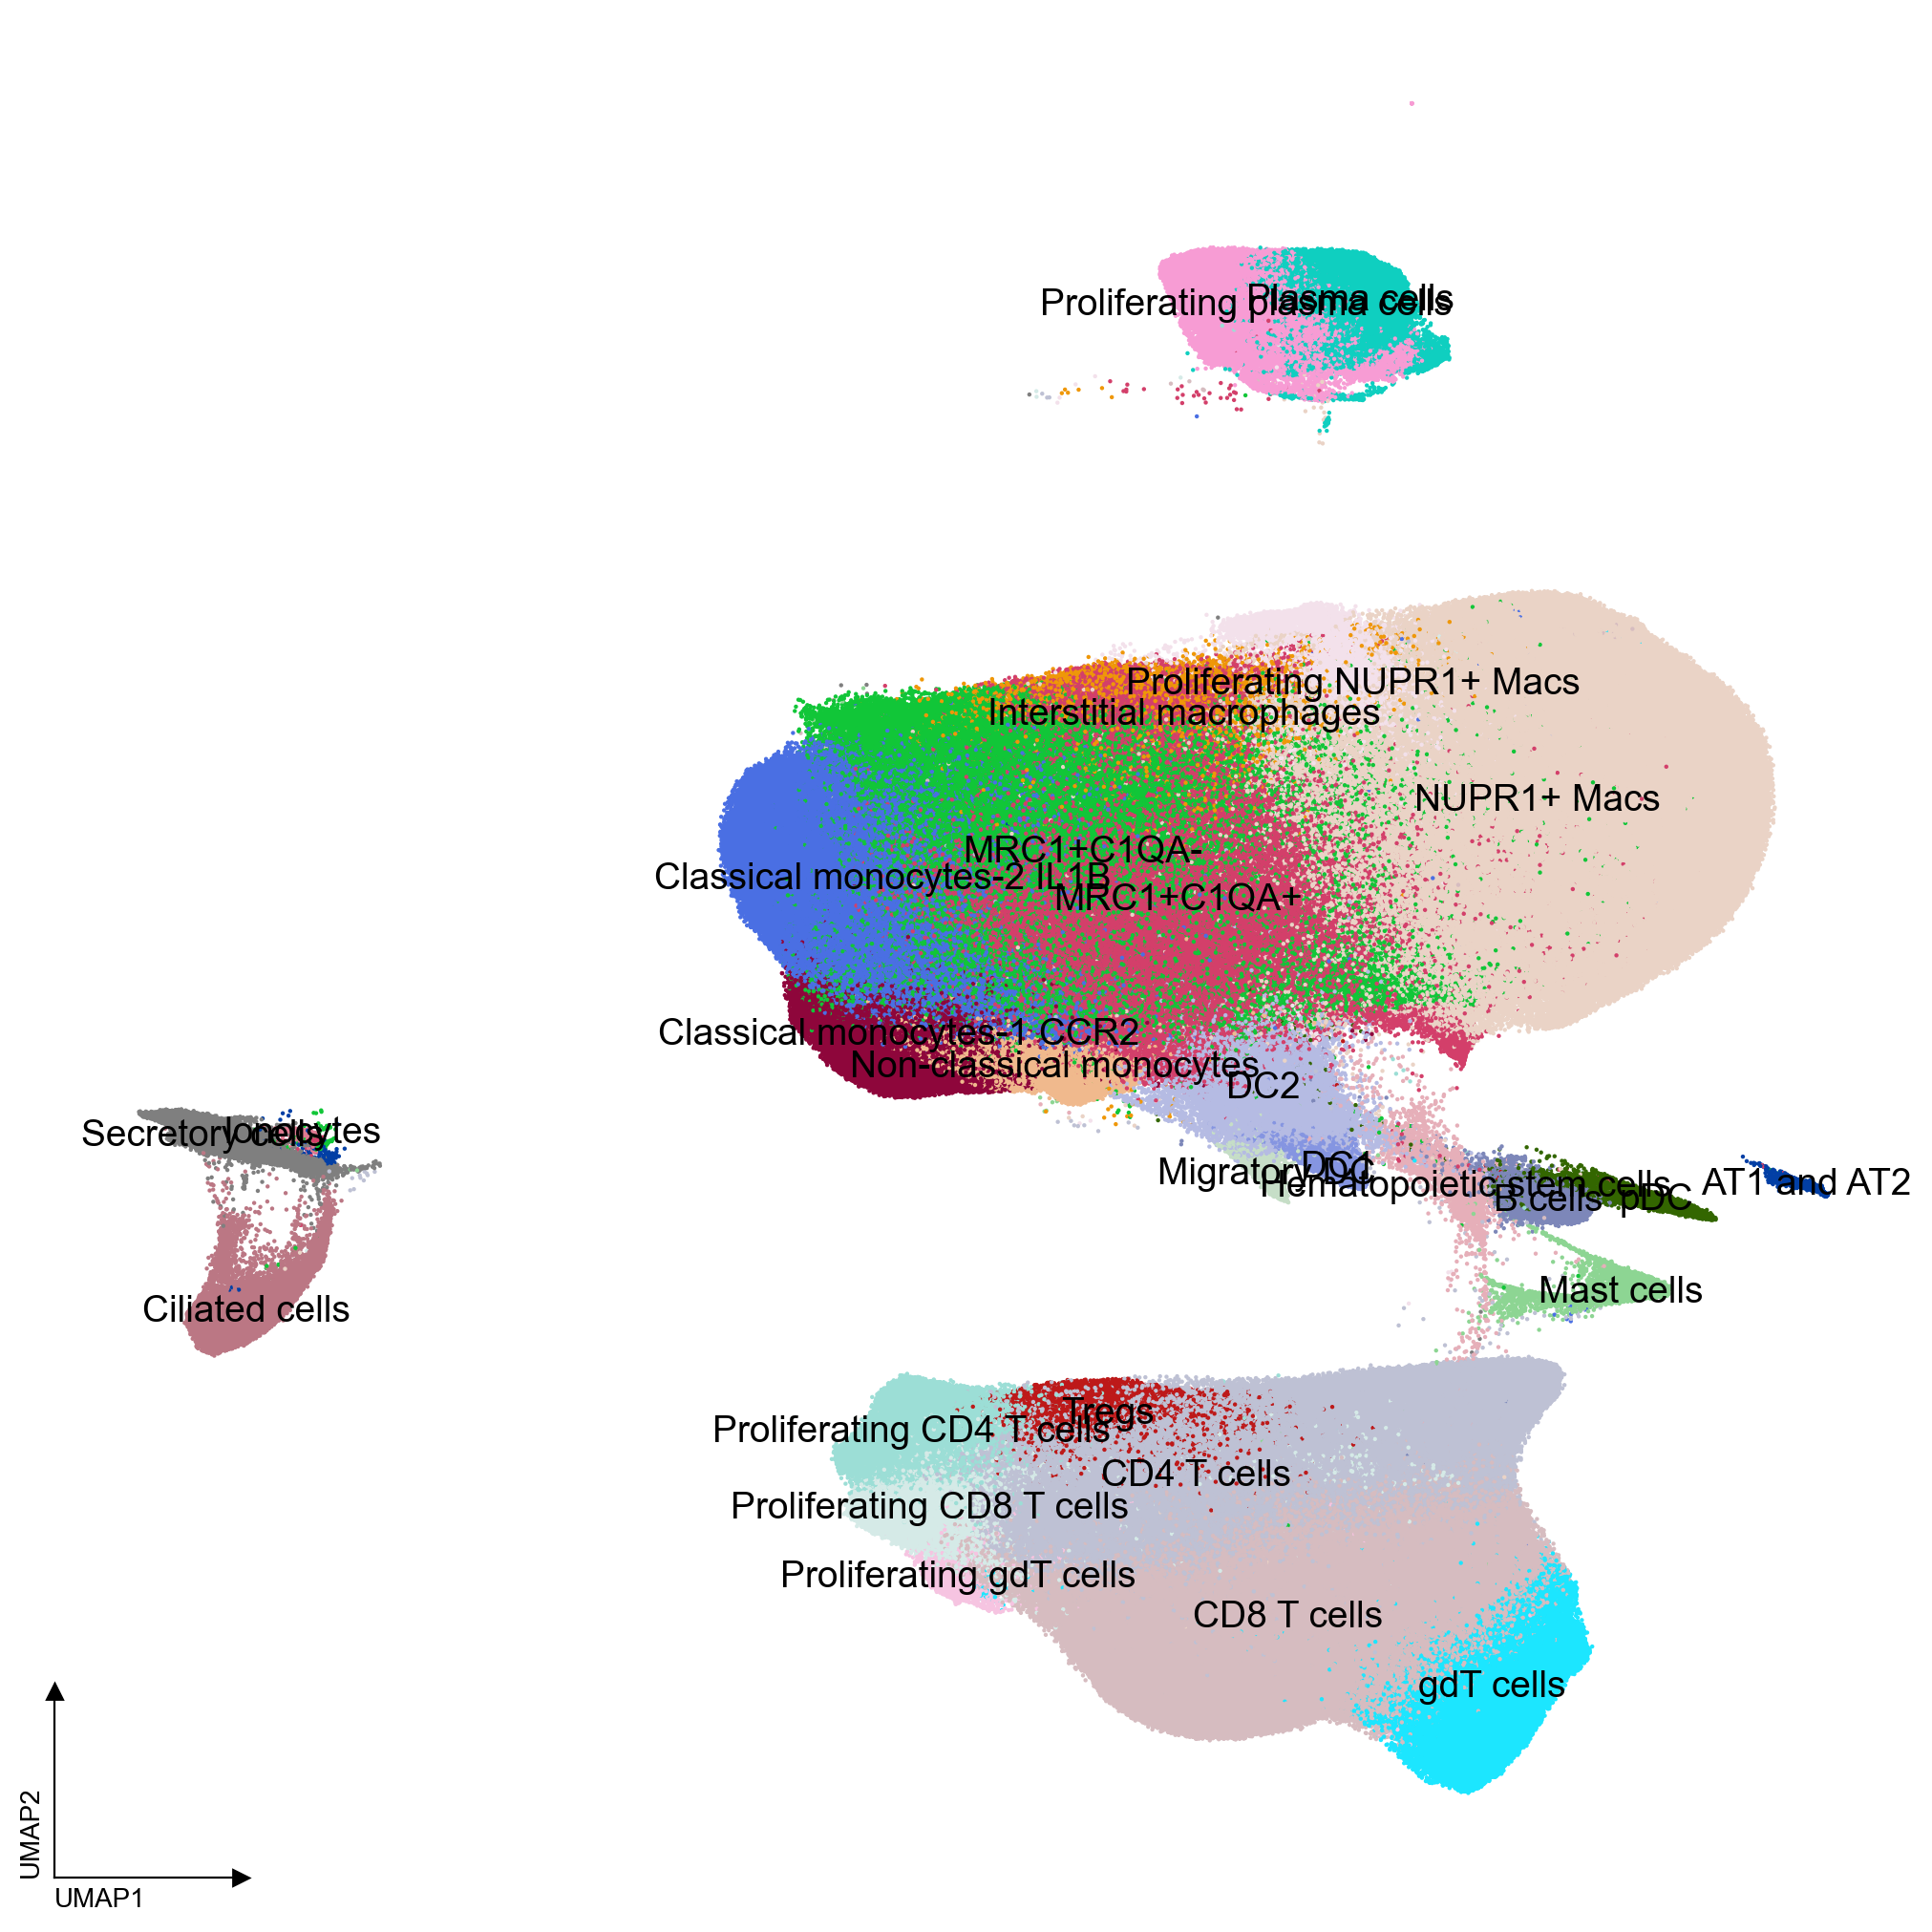

In [10]:
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
sc.pl.umap(
    ds,
    color='Level_6',
    legend_loc='on data',
    ax=ax,
    legend_fontweight='normal',
    legend_fontsize=14,
    title='',
    show=False,
    size=10
)
shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

width = xlim[1] - xlim[0]
height = ylim[1] - ylim[0]
xbound = xlim[0] + (width) * shrink_by
ybound = ylim[0] + (height) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel(ax.get_xlabel(), x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel(ax.get_ylabel(), y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.collections[0].set_rasterized(True)
fig.savefig('00_figures/Figure_2D_umap_simple.pdf', dpi=300)

In [11]:
ds.obs.patient.nunique()

206

In [12]:
ds.obs.library_id.nunique()

337

In [13]:
ds.obs.groupby('library_id').size().describe()

count      337.000000
mean      7236.415430
std       3685.445117
min        220.000000
25%       4519.000000
50%       6845.000000
75%       9781.000000
max      23319.000000
dtype: float64

In [14]:
ds.obs.Level_6.nunique()

28

In [15]:
ds.shape[0]

2438672

In [11]:
ds.raw.var.index.str.startswith('SARS-CoV-2').sum()

12

In [12]:
ds.raw.var_names[ds.raw.var.index.str.startswith('SARS-CoV-2')]

Index(['SARS-CoV-2_ORF1ab', 'SARS-CoV-2_S', 'SARS-CoV-2_ORF3a', 'SARS-CoV-2_E',
       'SARS-CoV-2_M', 'SARS-CoV-2_ORF6', 'SARS-CoV-2_ORF7a',
       'SARS-CoV-2_ORF7b', 'SARS-CoV-2_ORF8', 'SARS-CoV-2_N',
       'SARS-CoV-2_ORF10', 'SARS-CoV-2_SARS-CoV-2-antisense'],
      dtype='object')

In [13]:
(ds.raw.X[:, ds.raw.var.index.str.startswith('SARS-CoV-2')] > 0).sum(axis=0)

matrix([[13140,  5773,  2802,   764,  4199,  1339,  4201,  1420,  4709,
         20800,  3999,  4591]])

In [16]:
sars_expr = ds.raw.X[:, ds.raw.var.index.str.startswith('SARS-CoV-2')].sum(axis=1)

In [17]:
ds.obs['sars_expr'] = np.asarray(sars_expr).flatten()

<Axes: ylabel='Frequency'>

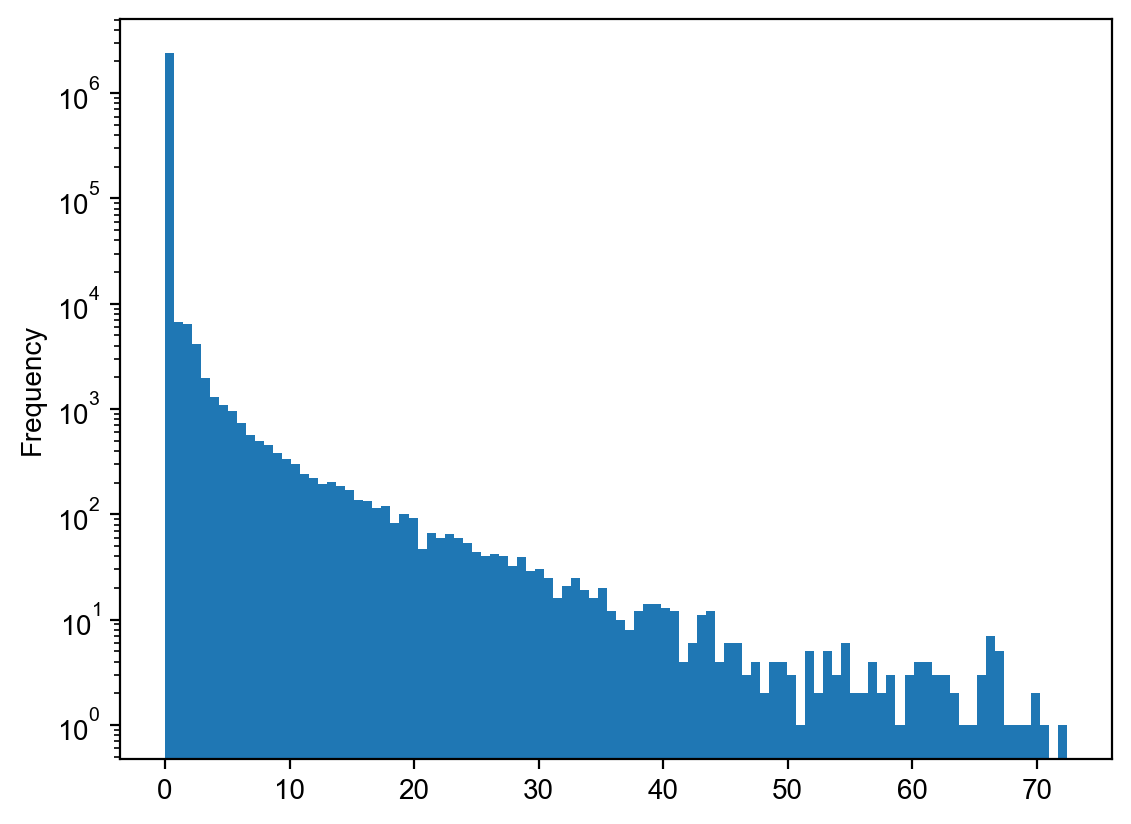

In [18]:
ds.obs.sars_expr.plot.hist(bins=100, log=True)

In [19]:
ds.obs['sars_expr_rel'] = ds.obs.sars_expr / ds.obs.total_counts

In [20]:
sars_ngenes = (ds.raw.X[:, ds.raw.var.index.str.startswith('SARS-CoV-2')] > 0).sum(axis=1)
ds.obs['sars_ngenes'] = np.asarray(sars_ngenes).flatten()

In [21]:
def expr_colormap():
    """\
    Gray-to-blue colormap for expression data
    """
    cdict = {
        'red':   [
            (0.0, 220/256, 220/256),
            (0.5, 42/256, 42/256),
            (1.0, 6/256, 6/256)
        ],

        'green': [
            (0.0, 220/256, 220/256),
            (0.5, 145/256, 145/256),
            (1.0, 37/256, 27/256)
        ],

        'blue':  [
            (0.0, 220/256, 220/256),
            (0.5, 174/256, 174/256),
            (1.0, 170/256, 170/256)
        ]
    }
    return mpl.colors.LinearSegmentedColormap('exprCmap', segmentdata=cdict, N=256)

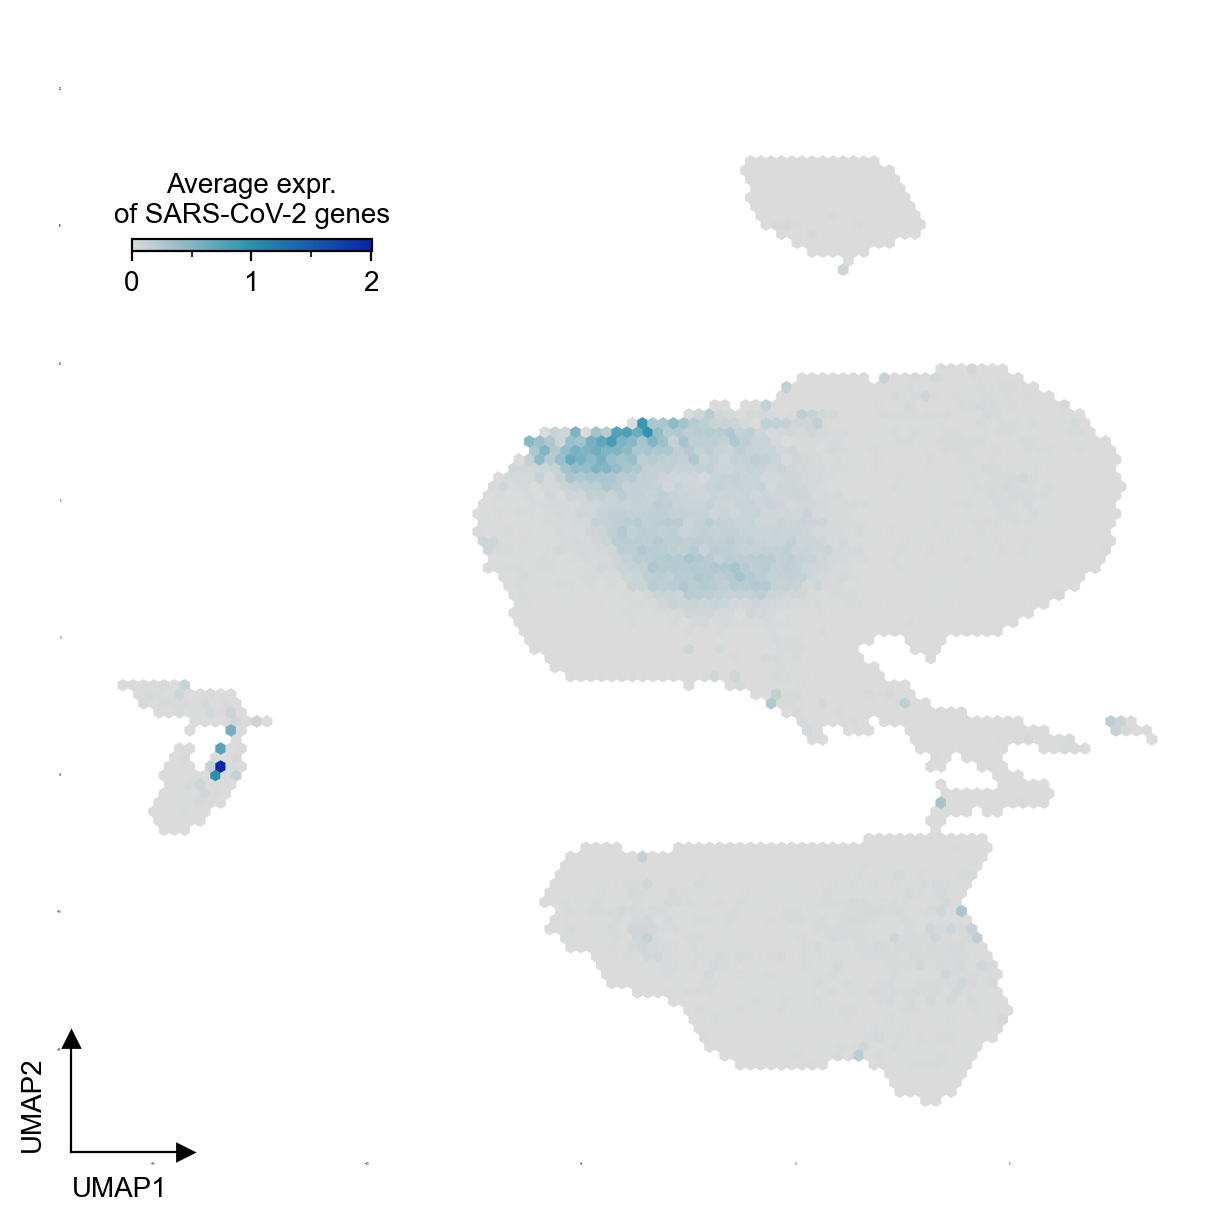

In [25]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

sars_expr_copy = ds.obs.sars_expr.copy()
q99 = np.percentile(sars_expr_copy, 99.9)
sars_expr_copy[sars_expr_copy > q99] = q99
# sars_expr_copy[sars_expr_copy < 1] = 0

# cmap = copy.copy(plt.get_cmap('flare'))
# cmap.set_under('#ddd')
cmap = expr_colormap()

hb = ax.hexbin(
    ds.obsm['X_umap'][:, 0],
    ds.obsm['X_umap'][:, 1],
    C=sars_expr_copy,
    # C=sc.get.obs_df(ds, 'SARS-CoV-2_N', use_raw=True),
    cmap=cmap,
    # clim=(0.005, None),
    gridsize=100,
    linewidths=0.15,
    mincnt=10,
    # bins=10,
    # reduce_C_function=lambda x: len(x) == 0 and np.nan or np.mean([y for y in x if y > 0])
    # reduce_C_function=lambda x: len(x) == 0 and np.nan or np.mean(x)
)
shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel("UMAP1", x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel("UMAP2", y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.collections[0].set_rasterized(True)
ax.tick_params(size=0, labelsize=0)

# norm = plt.Normalize(sars_expr_copy.min(), sars_expr_copy.quantile(0.99))
sm = plt.cm.ScalarMappable(cmap=hb.cmap, norm=hb.norm)
sm.set_array([])

cax = fig.add_axes((0.1, 0.8, 0.2, 0.01))

ax.figure.colorbar(
    sm,
    cax=cax,
    # label='$IFNG$',
    # title='$IFNG$ expression',
    orientation='horizontal',
    ticks=[0, 1, 2]
)
cax.set_title('Average expr.\nof SARS-CoV-2 genes', fontsize=10)
cax.set_xticks([0.5, 1.5], minor=True)

fig.savefig('00_figures/13_sars_cov_2_expr.pdf', dpi=300)

## Markers plot

In [ ]:
markers = pd.read_csv(common_data._sc_root / '09_final_full/09_final_full-markers.csv', index_col=0)

In [10]:
markers.cluster.nunique()

28

In [11]:
ds.obs.Level_6.nunique()

28

In [12]:
pd.Series(ds.obs.Level_6.unique()).isin(markers.cluster).sum()

27

In [13]:
cell_types = pd.Series(ds.obs.Level_6.unique())
cell_types[~cell_types.isin(markers.cluster)]

19    Interstitial macrophages
dtype: category
Categories (28, object): ['AT1 and AT2', 'B cells', 'CD4 T cells', 'CD8 T cells', ..., 'Secretory cells', 'Tregs', 'gdT cells', 'pDC']

In [14]:
markers.cluster = markers.cluster.replace({'Perivascular macrophages': 'Interstitial macrophages'})

In [15]:
pd.Series(ds.obs.Level_6.unique()).isin(markers.cluster).sum()

28

In [16]:
to_plot = markers.groupby('cluster').head(2)

In [17]:
to_plot.loc[to_plot.gene.duplicated()]

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
300,0.0,4.941221,0.933024,0.445452,0.0,Classical monocytes-2 IL1B,S100A8
616,0.0,2.892028,0.514494,0.163052,0.0,MRC1+C1QA-,CCL2
1007,0.0,6.123730,0.862376,0.048429,0.0,Proliferating CD8 T cells,MKI67
1018,0.0,5.769873,0.759962,0.042942,0.0,Proliferating CD8 T cells,TYMS
1068,0.0,5.379499,0.830125,0.045990,0.0,Proliferating NUPR1+ Macs,MKI67
1151,0.0,9.617258,0.989635,0.029316,0.0,Proliferating plasma cells,JCHAIN
1150,0.0,8.338412,0.995025,0.043130,0.0,Proliferating plasma cells,MZB1


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


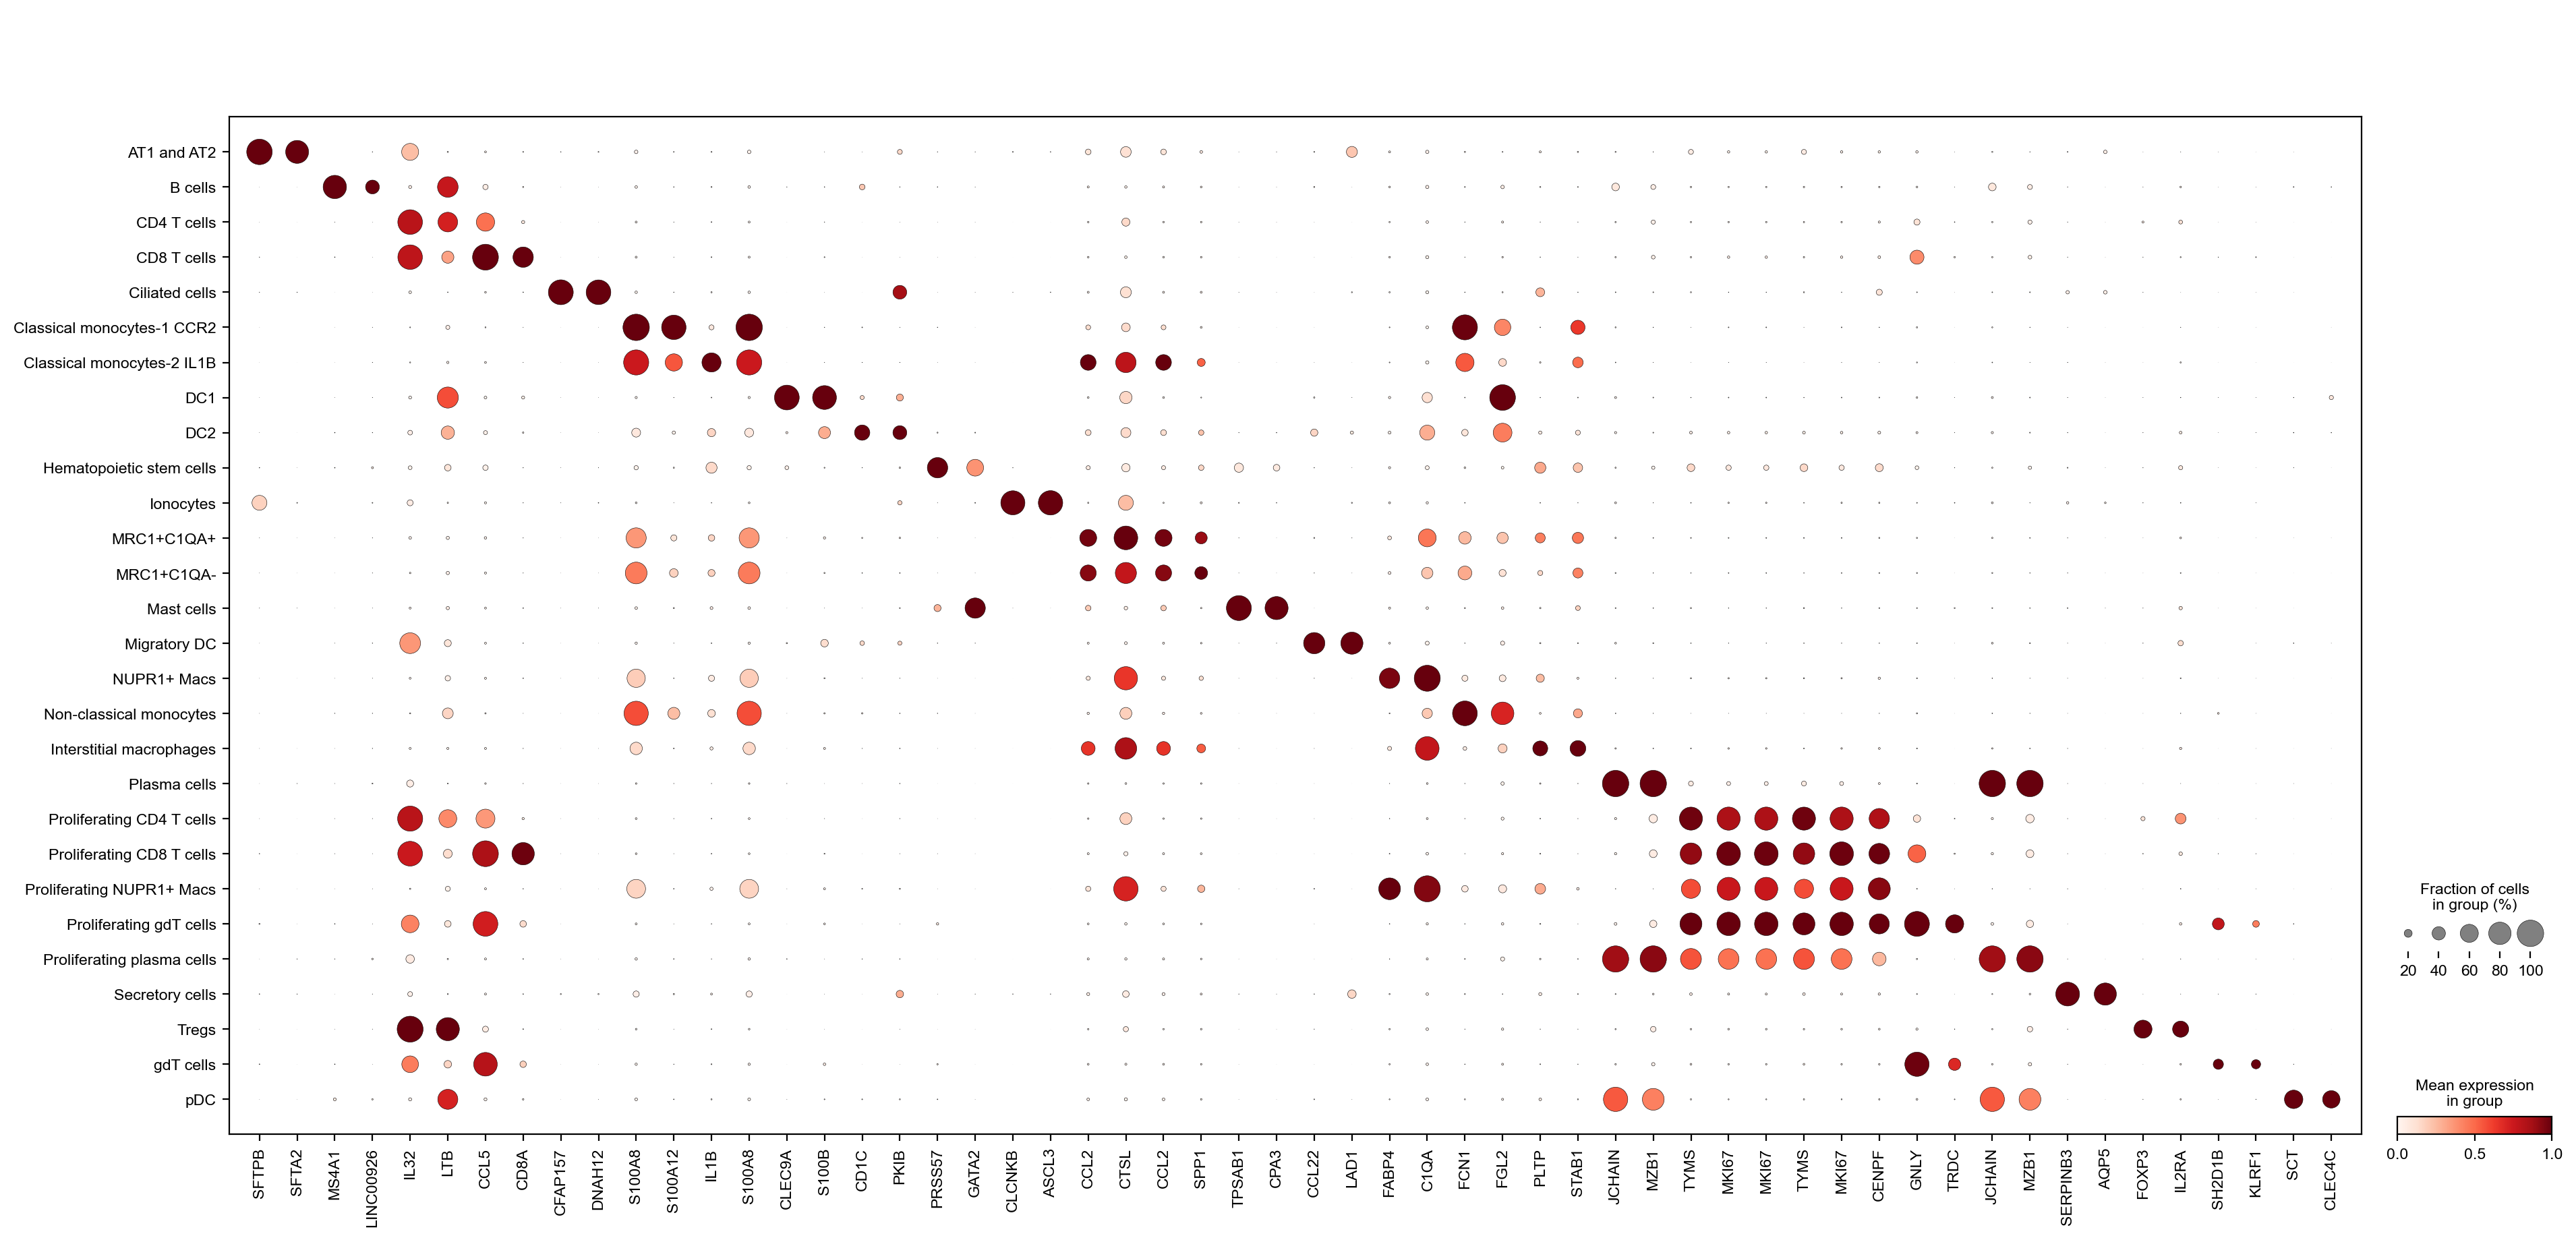

In [18]:
sc.pl.dotplot(ds, var_names=to_plot.gene, groupby='Level_6', use_raw=True, standard_scale='var')

In [19]:
ds.obs['Level_6_or'] = pd.Categorical(ds.obs.Level_6, categories=[
    'NUPR1+ Macs',
    'MRC1+C1QA+',
    'MRC1+C1QA-',
    'Classical monocytes-2 IL1B',
    'Classical monocytes-1 CCR2',
    'Non-classical monocytes',
    'Interstitial macrophages',

    'DC2',
    'DC1',
    'Migratory DC',

    'CD4 T cells',
    'CD8 T cells',
    'gdT cells',
    'Tregs',

    'B cells',
    'Plasma cells',
    'pDC',
    'Mast cells',
    'Hematopoietic stem cells',

    'AT1 and AT2',
    'Ciliated cells',
    'Secretory cells',
    'Ionocytes',

    'Proliferating NUPR1+ Macs',
    'Proliferating CD4 T cells',
    'Proliferating CD8 T cells',
    'Proliferating gdT cells',
    'Proliferating plasma cells',
])

In [20]:
to_plot.cluster = pd.Categorical(to_plot.cluster, categories=ds.obs.Level_6_or.cat.categories)

/tmp/ipykernel_1051782/397009121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot.cluster = pd.Categorical(to_plot.cluster, categories=ds.obs.Level_6_or.cat.categories)


In [21]:
to_plot = to_plot.sort_values(['cluster', 'avg_logFC'], ascending=[True, False])

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


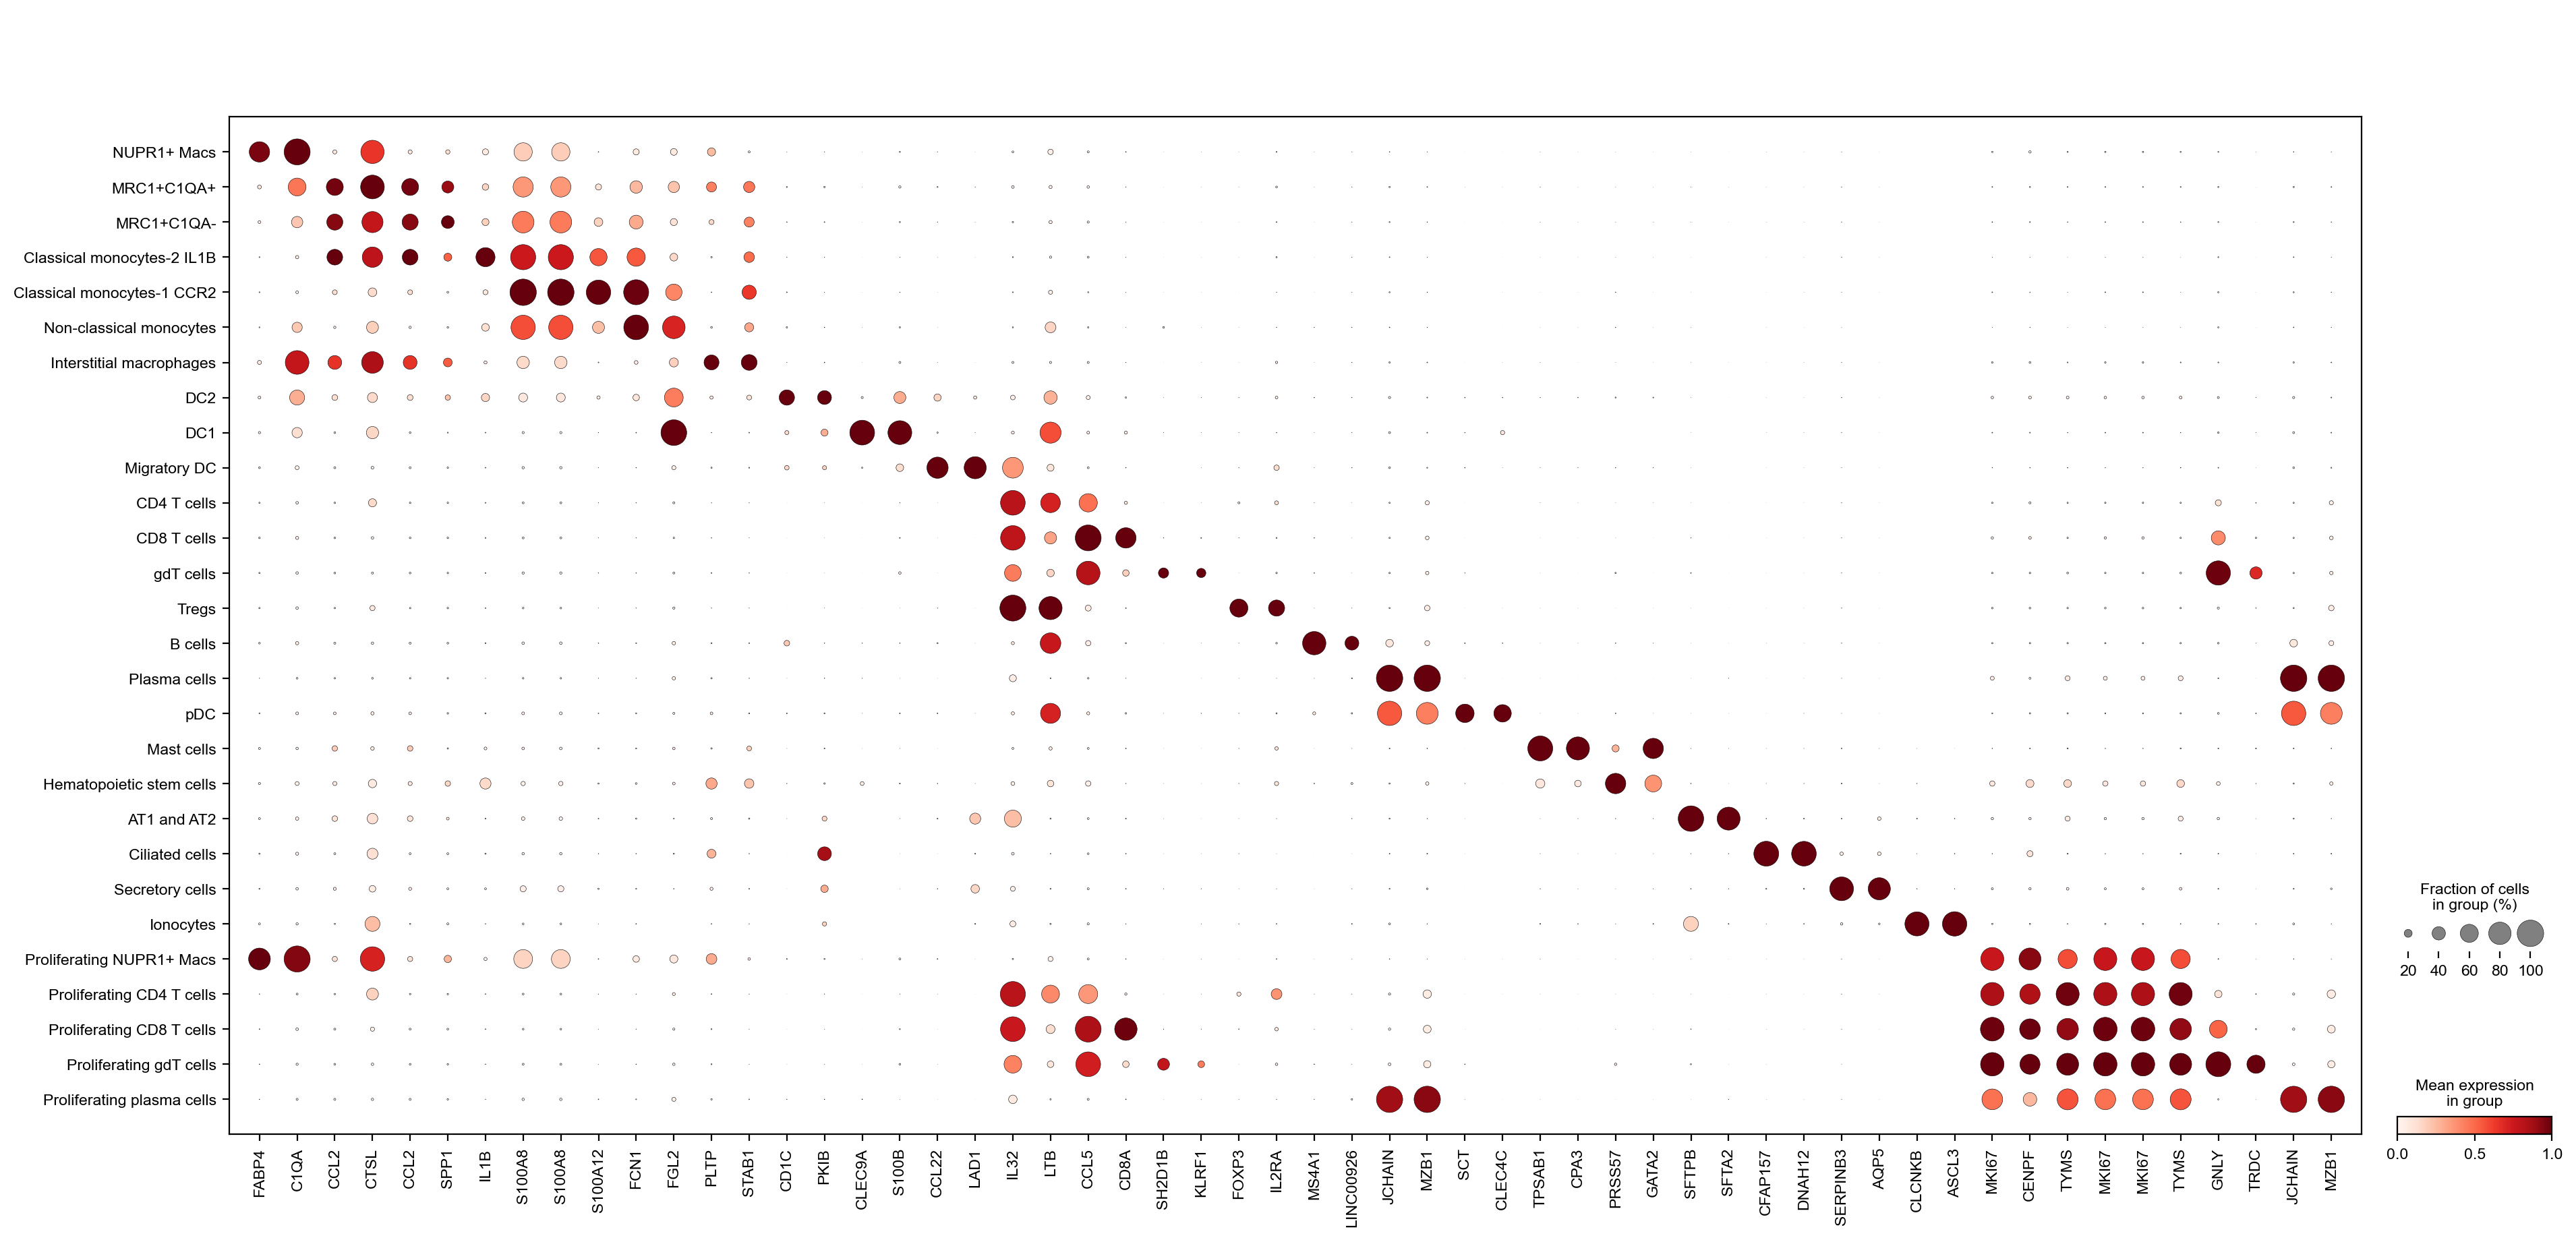

In [22]:
sc.pl.dotplot(ds, var_names=to_plot.gene, groupby='Level_6_or', use_raw=True, standard_scale='var')

In [25]:
marker_genes = """INHBA FABP4 MARCO NUPR1 MRC1 C1QA CCL2 SPP1 CLEC5A CD300E G0S2 IL1B CCR2 S100A12 VCAN FCN1
FCGR3A CX3CR1 PLTP CCL13 CD1C CLEC10A CLEC9A S100B CCL22 LAMP3 CD3G TRAC IL32 LTB CCL5 CD8A KLRF1 TRDC
FOXP3 IL2RA MS4A1 CD79A JCHAIN MZB1 CLEC4C SCT CPA3 TPSAB1 CD34 PRSS57 SFTPB SFTA2 FOXJ1 TPPP3
SERPINB3 AQP5 CLCNKB ASCL3 MKI67 TOP2A CENPF""".split()

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


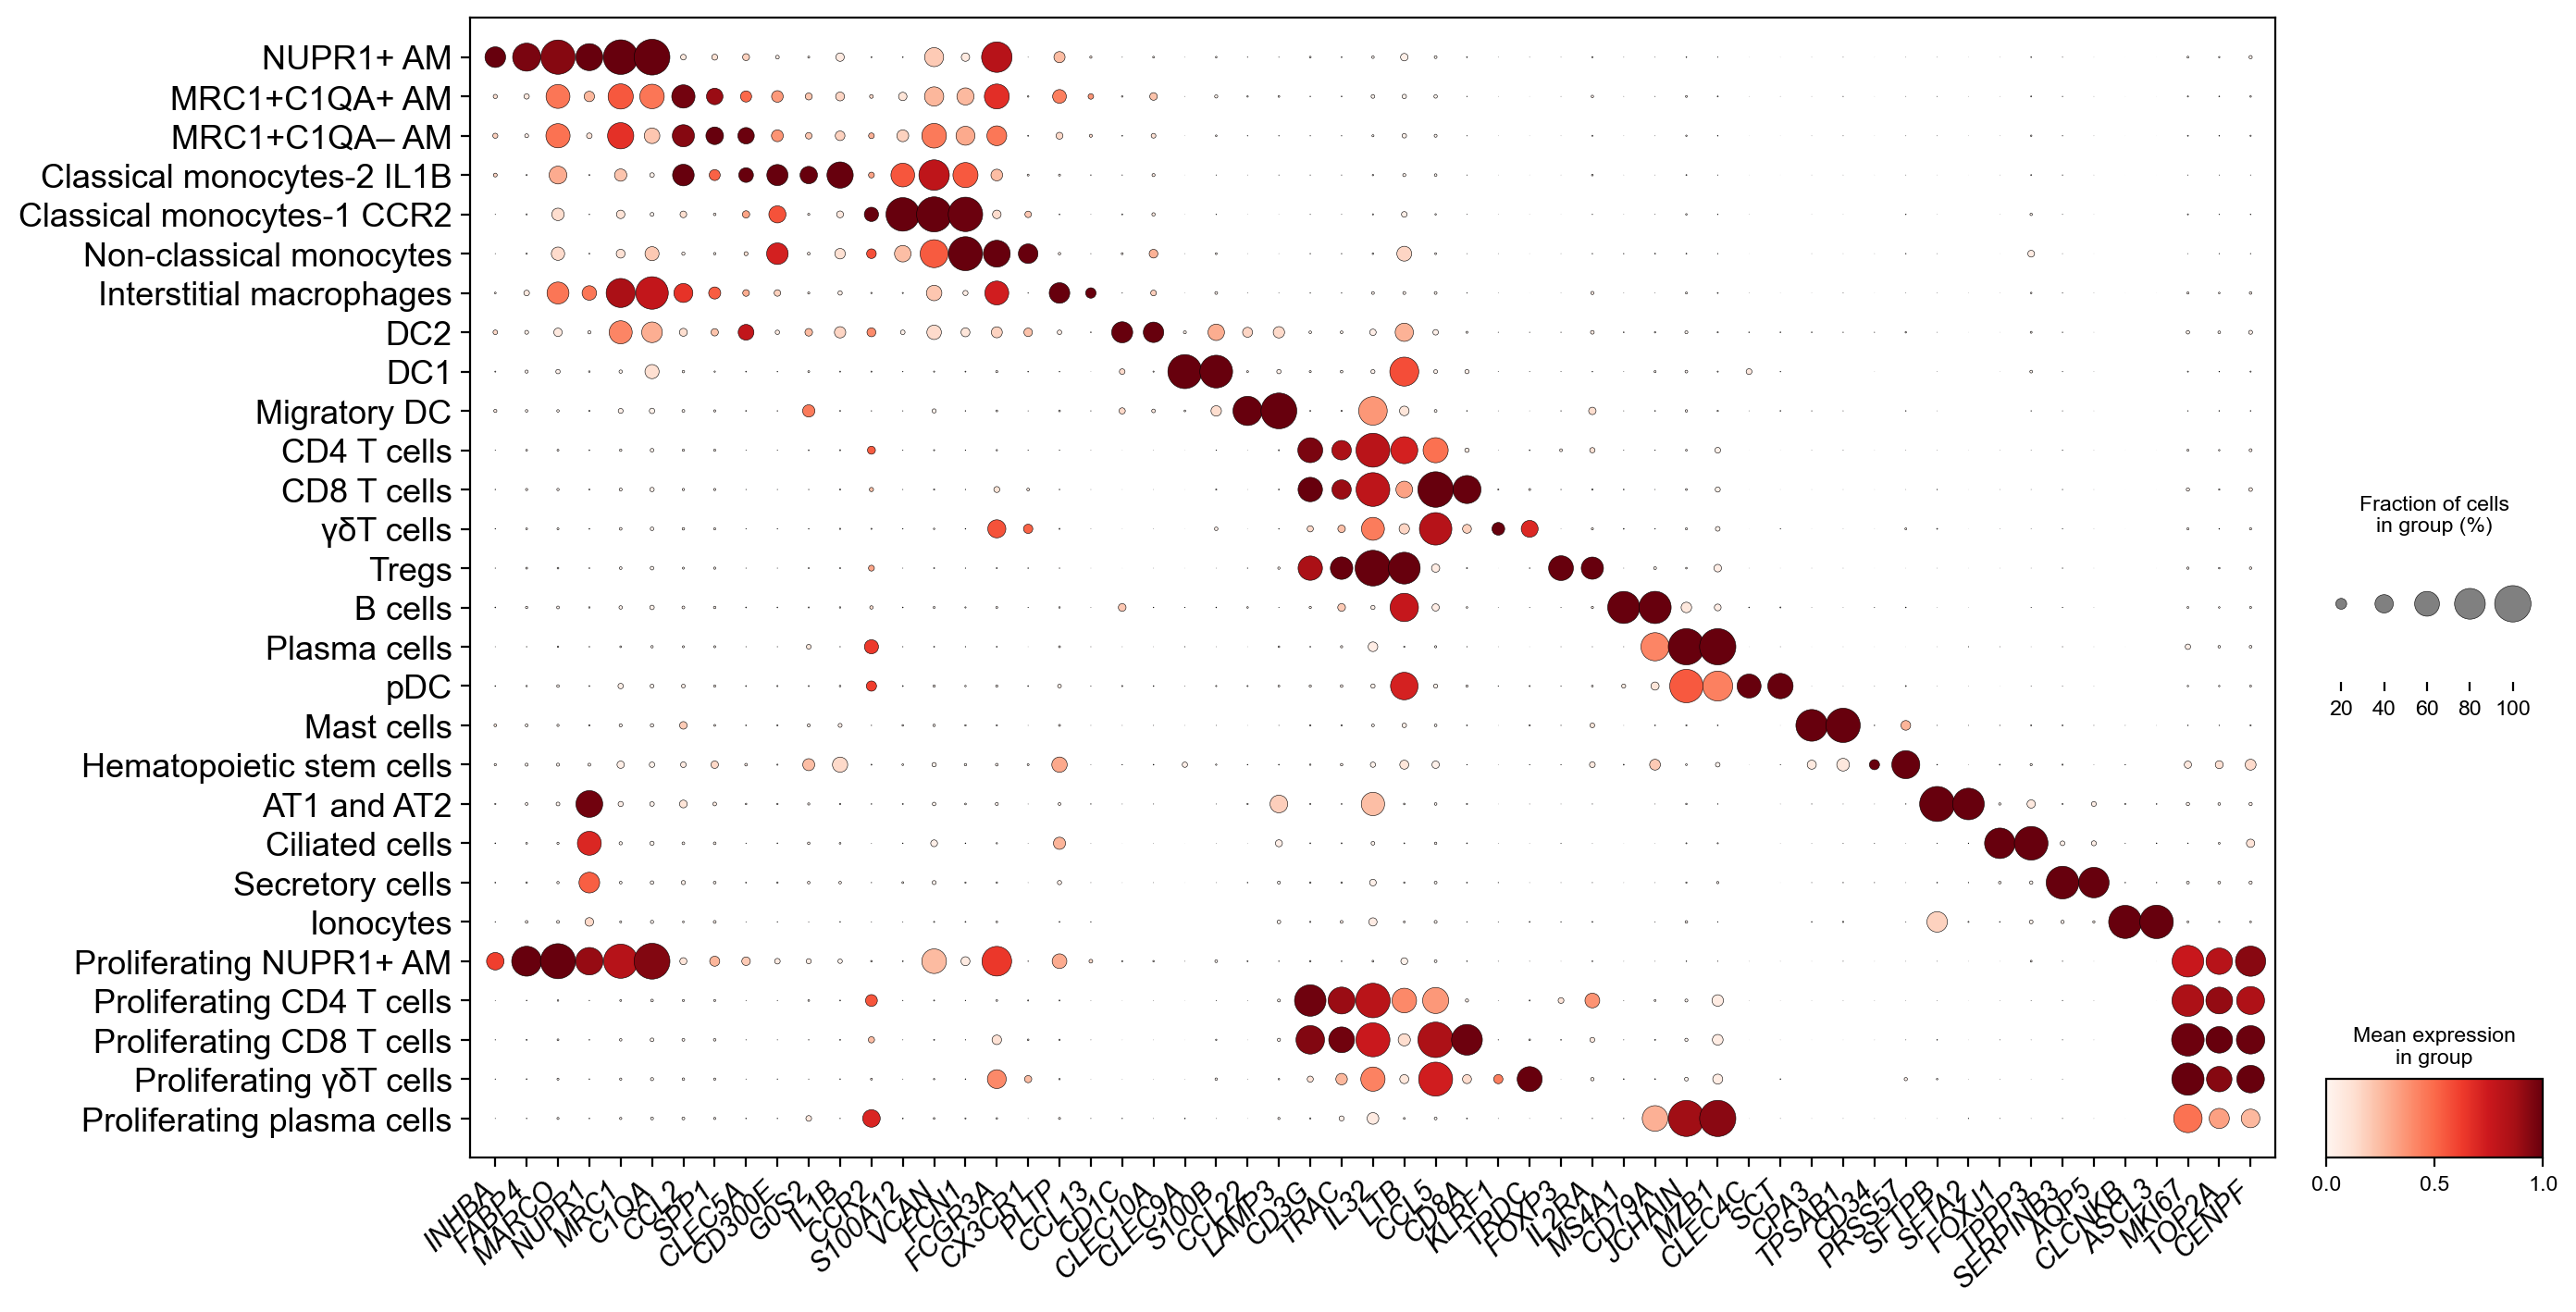

In [31]:
dotplot = sc.pl.dotplot(
    ds,
    var_names=marker_genes,
    groupby='Level_6_or',
    use_raw=True,
    standard_scale='var',
    return_fig=True,
    figsize=(14, 7)
)
ax = dotplot.get_axes().get('mainplot_ax')
ax.set_yticklabels(
    [common_plots.CELL_TYPES_DISPLAY.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()],
    size=13
)
trans = mpl.transforms.Affine2D().translate(4, 0)
for t in ax.get_xticklabels():
    t.set_fontstyle('italic')
    t.set_rotation(45)
    t.set_ha('right')
    t.set_size(11)
    t.set_transform(t.get_transform() + trans)
dotplot.fig.subplots_adjust(left=0.18, top=0.98, right=0.98, bottom=0.1)
dotplot.fig.savefig("00_figures/13_markers.pdf")

In [83]:
markers.loc[markers.cluster.eq('MRC1+C1QA-')]

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
616,0.0,2.892028,0.514494,0.163052,0.0,MRC1+C1QA-,CCL2
632,0.0,2.824492,0.380032,0.109350,0.0,MRC1+C1QA-,SPP1
608,0.0,2.445800,0.767315,0.417602,0.0,MRC1+C1QA-,S100A8
638,0.0,2.389251,0.346602,0.099246,0.0,MRC1+C1QA-,CLEC5A
602,0.0,2.336331,0.849622,0.545207,0.0,MRC1+C1QA-,TIMP1
636,0.0,2.300072,0.379300,0.123493,0.0,MRC1+C1QA-,EMP1
613,0.0,2.048257,0.815523,0.511569,0.0,MRC1+C1QA-,S100A9
624,0.0,1.849372,0.593670,0.299507,0.0,MRC1+C1QA-,VCAN
600,0.0,1.730294,0.931920,0.696407,0.0,MRC1+C1QA-,CTSB
634,0.0,1.712060,0.511672,0.269115,0.0,MRC1+C1QA-,ANPEP


In [97]:
ifng_expr = ds.raw.X[:, ds.raw.var.index.get_loc('IFNG')].todense().A1

In [104]:
pd.Series(ifng_expr).describe()

count    2.452841e+06
mean     5.058162e-02
std      3.141403e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.000682e+00
dtype: float64

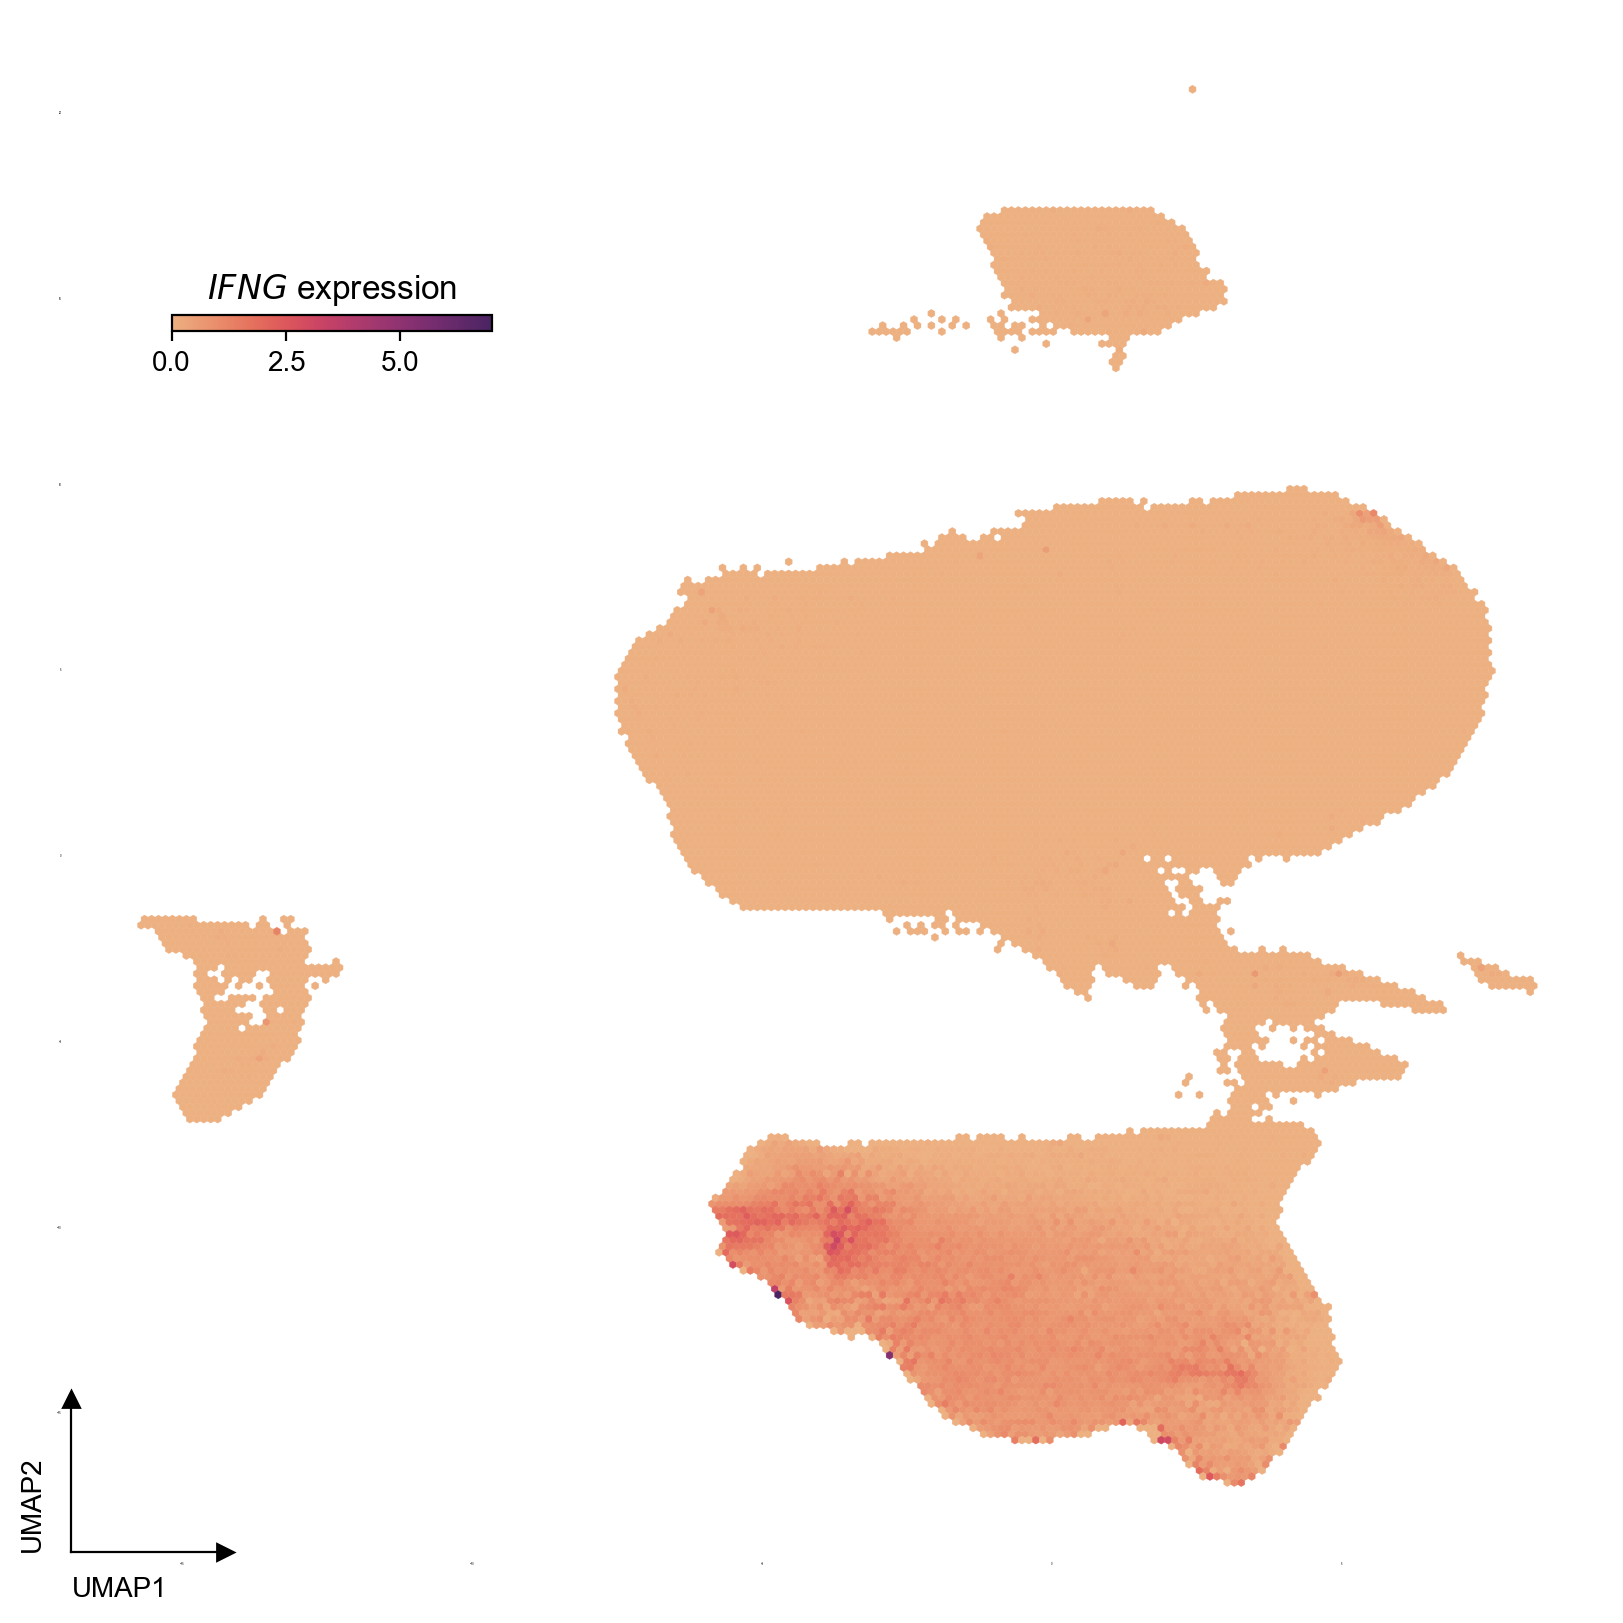

In [106]:
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

ifng_expr_copy = ifng_expr.copy()
# q99 = np.percentile(ifng_expr_copy, 99.9)
# ifng_expr_copy[ifng_expr_copy > q99] = q99

ax.hexbin(
    ds.obsm['X_umap'][:, 0],
    ds.obsm['X_umap'][:, 1],
    C=ifng_expr_copy,
    cmap='flare',
    gridsize=200,
    linewidths=0.15
)
shrink_by = 0.1
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by

b = ax.spines["bottom"]
b.set_bounds(xlim[0], xbound)
ax.set_xlabel("UMAP1", x=0, ha="left")
ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)

b = ax.spines["left"]
b.set_bounds(ylim[0], ybound)
ax.set_ylabel("UMAP2", y=0, ha="left")
ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.collections[0].set_rasterized(True)
ax.tick_params(size=0, labelsize=0)

norm = plt.Normalize(ifng_expr_copy.min(), ifng_expr_copy.max())
sm = plt.cm.ScalarMappable(cmap='flare', norm=norm)
sm.set_array([])

cax = fig.add_axes((0.1, 0.8, 0.2, 0.01))

ax.figure.colorbar(
    sm,
    cax=cax,
    # label='$IFNG$',
    # title='$IFNG$ expression',
    orientation='horizontal',
    # ticks=[0, 2, 4, 5]
)
cax.set_title('$IFNG$ expression', fontsize=12)

fig.savefig('00_figures/Figure_2D_ifng.pdf', dpi=300)